<a href="https://colab.research.google.com/github/rsjogdand2005-prog/Real-time-vehicle-traffic-analysis/blob/main/project_big_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Load dataset
!unzip -o /content/archive.zip -d /content/
df = pd.read_csv("scaled_vehicle_data.csv")

# Display first rows
print(df.head())

Archive:  /content/archive.zip
  inflating: /content/scaled_vehicle_data.csv  
  inflating: /content/vehicle_data_with_speed (2).csv  
   Frame  Car_Count  Truck_Count  Bike_Count  Bus_Count  2_Wheeler_Count  \
0      0        0.0          1.0         0.0        0.0              0.0   
1      1        0.0          0.0         0.0        1.0              0.0   
2      2        0.0          0.0         0.0        0.0              0.0   
3      3        0.0          0.0         0.0        0.0              0.0   
4      4        0.0          0.0         0.0        0.0              0.0   

   3_Wheeler_Count  4_Wheeler_Count  6_Wheeler_Count  Other_Vehicles  \
0              0.0              1.0              0.0             0.0   
1              0.0              0.0              1.0             0.0   
2              0.0              0.0              0.0             0.7   
3              0.0              0.0              0.0             0.7   
4              0.0              0.0             

In [ ]:
# Check missing values
print(df.isnull().sum())

# Drop missing values (or fill if needed)
df = df.dropna()

# 'timestamp' and related time features are not available in this dataset.
# The following lines have been commented out or removed.
# Convert timestamp to datetime
# df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract time features
# df['hour'] = df['timestamp'].dt.hour
# df['day'] = df['timestamp'].dt.day
# df['weekday'] = df['timestamp'].dt.weekday

Frame                0
Car_Count            0
Truck_Count          0
Bike_Count           0
Bus_Count            0
2_Wheeler_Count      0
3_Wheeler_Count      0
4_Wheeler_Count      0
6_Wheeler_Count      0
Other_Vehicles       0
Avg_Speed_kmh        0
Time_To_Cross_sec    0
Total_Vehicles       0
Total Vehicles       0
Vehicle Density      0
dtype: int64


In [ ]:
# The 'weather' column is not available in this dataset, so its mapping is removed.
# df['weather'] = df['weather'].map({
#     'Clear': 0,
#     'Cloudy': 1,
#     'Rainy': 2
# })

# Convert 'Vehicle Density' to 'congestion_level' by discretizing.
# Assuming Vehicle Density is scaled between 0 and 1, we'll create three levels:
# 0: Low (0 to 0.33), 1: Medium (0.33 to 0.66), 2: High (0.66 to 1.0)
df['congestion_level'] = pd.cut(df['Vehicle Density'],
                                bins=[-0.01, 0.33, 0.66, 1.01],
                                labels=[0, 1, 2],
                                right=True)
# Convert the new column to integer type
df['congestion_level'] = df['congestion_level'].astype(int)

# Display value counts for the new congestion_level
print("Congestion Level Distribution:")
print(df['congestion_level'].value_counts())

Congestion Level Distribution:
congestion_level
1    1183
2     584
0      33
Name: count, dtype: int64


In [ ]:
df_full = pd.read_csv("vehicle_data_with_speed (2).csv")
display(df_full.head())

,Frame,Car_Count,Truck_Count,Bike_Count,Bus_Count,2_Wheeler_Count,3_Wheeler_Count,4_Wheeler_Count,6_Wheeler_Count,Other_Vehicles,Avg_Speed_kmh,Time_To_Cross_sec,Total_Vehicles
0,0,0,14,0,0,0,0,14,0,0,57.648919,0.000000,14
1,1,0,0,0,14,0,0,0,14,0,50.597562,0.033333,14
2,2,0,0,0,0,0,0,0,0,14,34.723332,0.066667,14
3,3,0,0,0,0,0,0,0,0,14,36.886923,0.100000,14
4,4,0,0,0,0,0,0,0,0,14,43.772491,0.133333,14


In [ ]:
display(df.head())

,Frame,Car_Count,Truck_Count,Bike_Count,Bus_Count,2_Wheeler_Count,3_Wheeler_Count,4_Wheeler_Count,6_Wheeler_Count,Other_Vehicles,Avg_Speed_kmh,Time_To_Cross_sec,Total_Vehicles,Total Vehicles,Vehicle Density
0,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.923075,0.000000,14,0.666667,0.666667
1,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.687564,0.000556,14,0.000000,0.000000
2,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.7,0.157373,0.001112,14,0.666667,0.666667
3,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.7,0.229636,0.001668,14,0.666667,0.666667
4,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.7,0.459610,0.002223,14,0.666667,0.666667


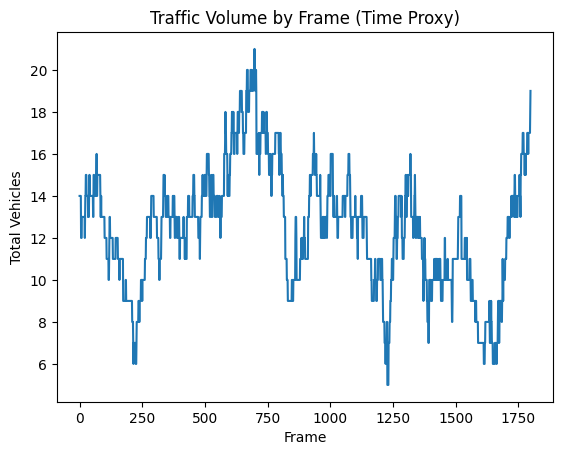

In [ ]:
plt.figure()
sns.lineplot(x='Frame', y='Total_Vehicles', data=df)
plt.title("Traffic Volume by Frame (Time Proxy)")
plt.xlabel("Frame")
plt.ylabel("Total Vehicles")
plt.show()

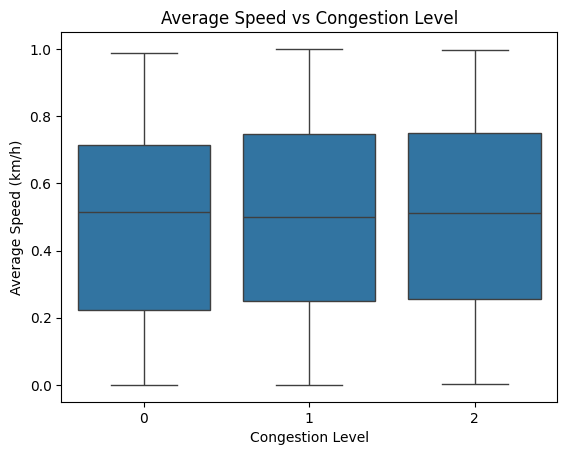

In [ ]:
plt.figure()
sns.boxplot(x='congestion_level', y='Avg_Speed_kmh', data=df)
plt.title("Average Speed vs Congestion Level")
plt.xlabel("Congestion Level")
plt.ylabel("Average Speed (km/h)")
plt.show()

In [ ]:
X = df[['Total_Vehicles', 'Avg_Speed_kmh']]
y = df['congestion_level']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Accuracy: 0.9361111111111111

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       0.94      0.96      0.95       232
           2       0.93      0.90      0.91       124

    accuracy                           0.94       360
   macro avg       0.87      0.87      0.87       360
weighted avg       0.94      0.94      0.94       360



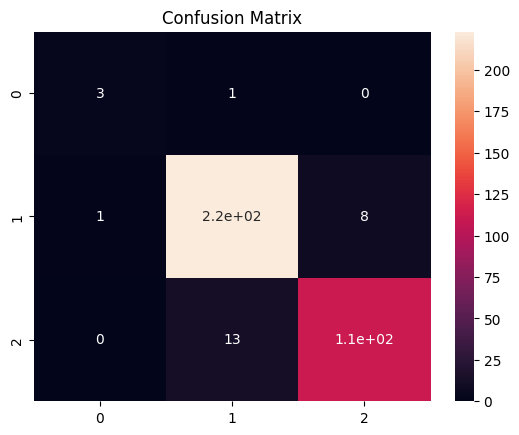

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
def predict_traffic(vehicle_count, speed):
    # The model was trained only on 'Total_Vehicles' and 'Avg_Speed_kmh'.
    # 'weather' and 'hour' are not features used by this trained model.
    input_data = np.array([[vehicle_count, speed]])

    prediction = model.predict(input_data)[0]

    level_map = {0: 'Low', 1: 'Medium', 2: 'High'}
    return level_map[prediction]


# Example
# Call predict_traffic with only the features the model expects
result = predict_traffic(80, 25) # Removed 'Clear' and 9 as these are not model features
print("Predicted Traffic:", result)

Predicted Traffic: High


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import random
import time

for i in range(5):
    vehicle_count = random.randint(20, 200)
    speed = random.randint(10, 60)

    prediction = predict_traffic(vehicle_count, speed)

    print(f"Vehicles: {vehicle_count}, Speed: {speed}")
    print("Traffic Level:", prediction)
    print("-" * 40)

    time.sleep(2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Vehicles: 86, Speed: 21
Traffic Level: High
----------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Vehicles: 179, Speed: 46
Traffic Level: High
----------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Vehicles: 168, Speed: 25
Traffic Level: High
----------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Vehicles: 200, Speed: 59
Traffic Level: High
----------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Vehicles: 98, Speed: 24
Traffic Level: High
----------------------------------------


In [ ]:
!pip install streamlit
import streamlit as st
import numpy as np
import pickle

# Load model
model = pickle.load(open("model.pkl", "rb"))

st.title("🚦 Traffic Prediction System")

vehicle_count = st.slider("Vehicle Count", 0, 200)
speed = st.slider("Speed", 0, 100)

if st.button("Predict"):
    input_data = np.array([[vehicle_count, speed]])
    prediction = model.predict(input_data)[0]

    level_map = {0: 'Low', 1: 'Medium', 2: 'High'}
    st.success(f"Traffic Level: {level_map[prediction]}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 89.6 MB/s eta 0:00:00


2026-04-14 09:54:12.111 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 09:54:12.541 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-14 09:54:12.543 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 09:54:12.545 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 09:54:12.548 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 09:54:12.551 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 09:54:12.553 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 09:54:12.555 Thread 'MainThread': mi

In [ ]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))

NameError: name 'model' is not defined